# Flight Price Prediction


## [Kaggle Dataset](https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for seaborn
sns.set(style="whitegrid")

In [2]:
df = pd.read_csv('Clean_Dataset.csv')
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


**Distribution of Flight Prices**

This plot will help us understand the range and distribution of flight prices.

C:\Users\sebas\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


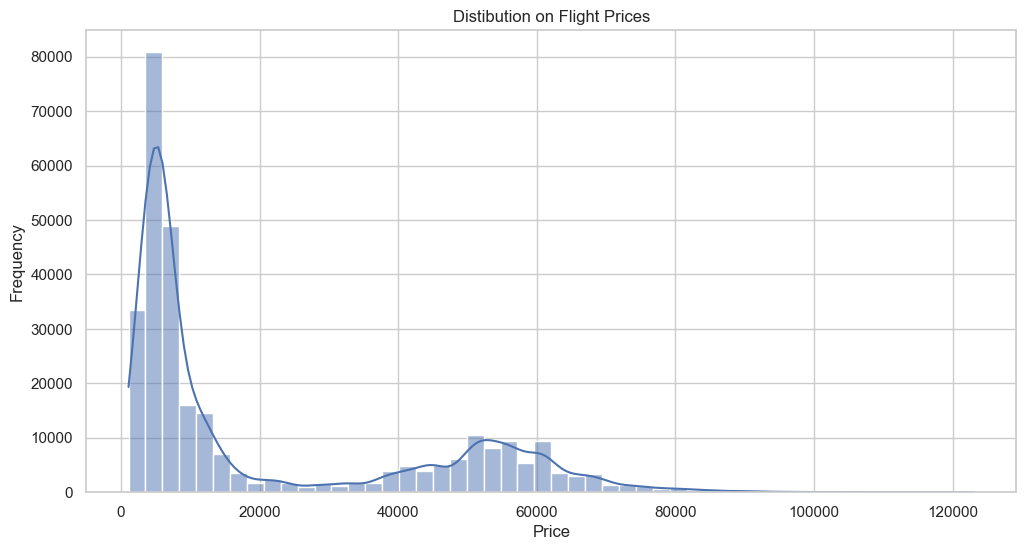

In [7]:
plt.figure(figsize=(12, 6))
sns.histplot(df['price'], bins=50, kde=True)
plt.title('Distibution on Flight Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

**Number of Flights by Airline**

This bar plot will show the number of flights operated by each airline.

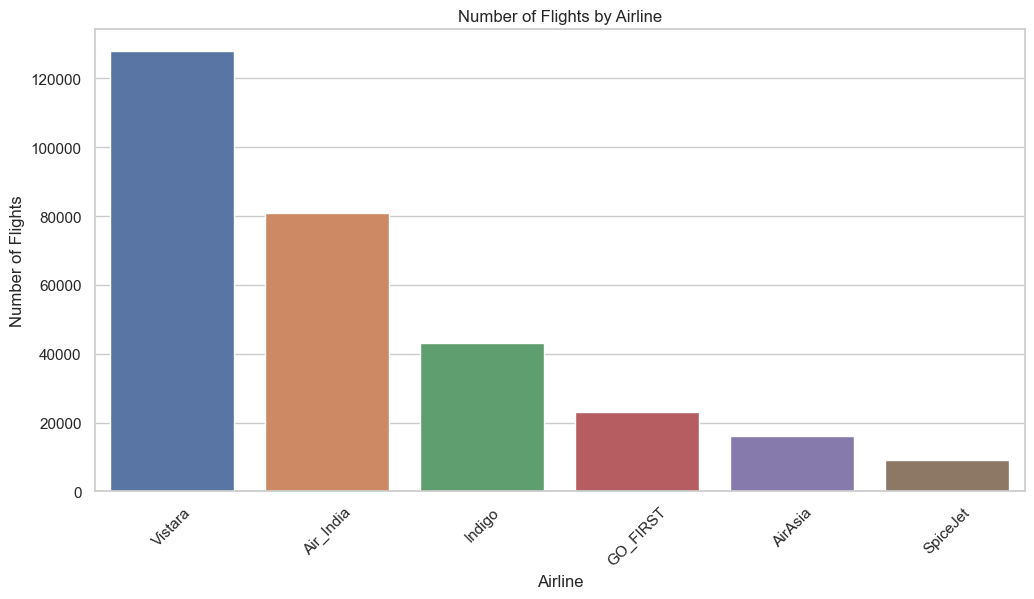

In [14]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='airline', order=df['airline'].value_counts().index)
plt.title('Number of Flights by Airline')
plt.xlabel('Airline')
plt.ylabel('Number of Flights')
plt.xticks(rotation=45)
plt.show()

**Flight Duration Distribution**

This plot will show how flight durations are distributed.

In [13]:
df.describe()['duration']

count    300153.000000
mean         12.221021
std           7.191997
min           0.830000
25%           6.830000
50%          11.250000
75%          16.170000
max          49.830000
Name: duration, dtype: float64

C:\Users\sebas\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


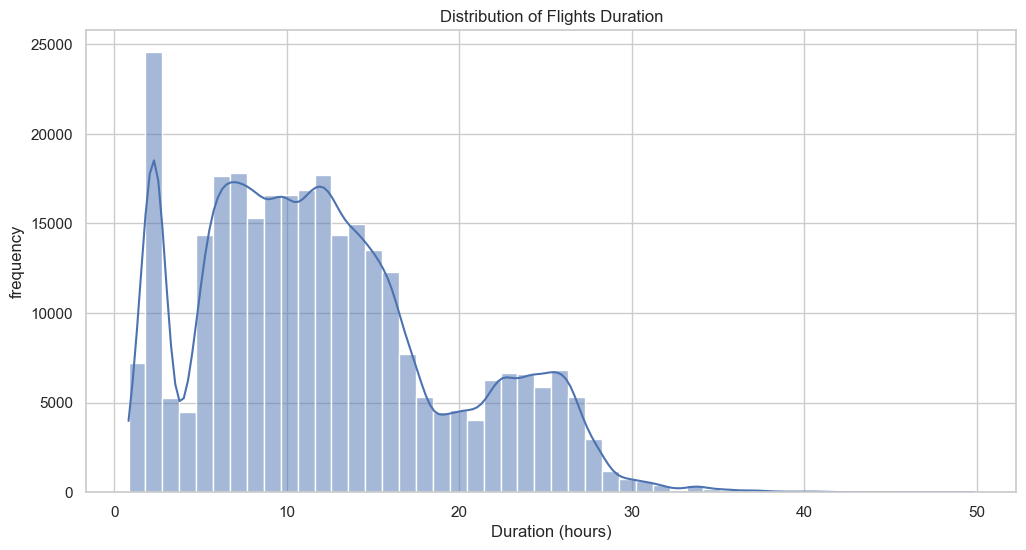

In [16]:
plt.figure(figsize=(12, 6))
sns.histplot(df['duration'], bins=50, kde=True)
plt.title('Distribution of Flights Duration')
plt.xlabel('Duration (hours)')
plt.ylabel('frequency')
plt.show()

**Price Distribution by Airline**

This box plot will show the distribution of prices for each airline.

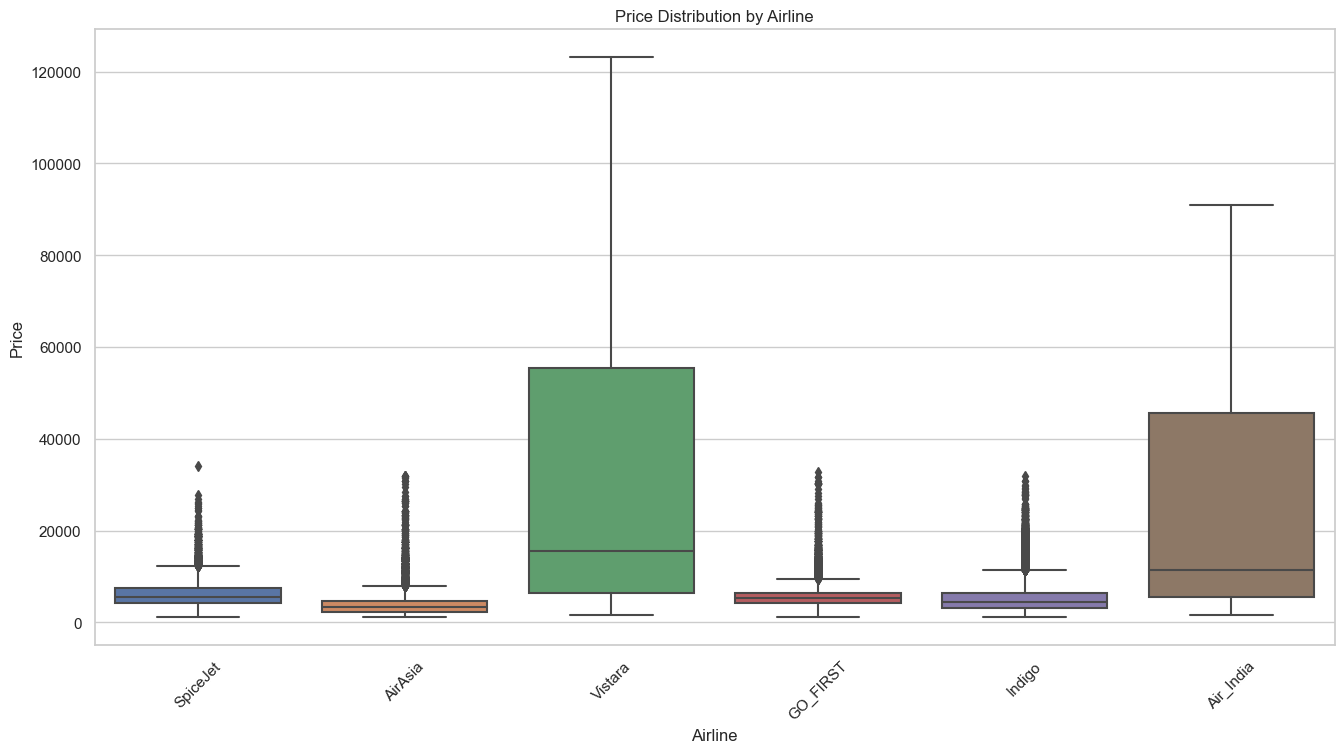

In [17]:
plt.figure(figsize=(16, 8))
sns.boxplot(data=df, x='airline', y='price')
plt.title('Price Distribution by Airline')
plt.xlabel('Airline')
plt.ylabel('Price')
plt.xticks(rotation=45)
plt.show()

**Flight Count by Source and Destination Cities**

This heatmap will show the count of flights between source and destination cities.

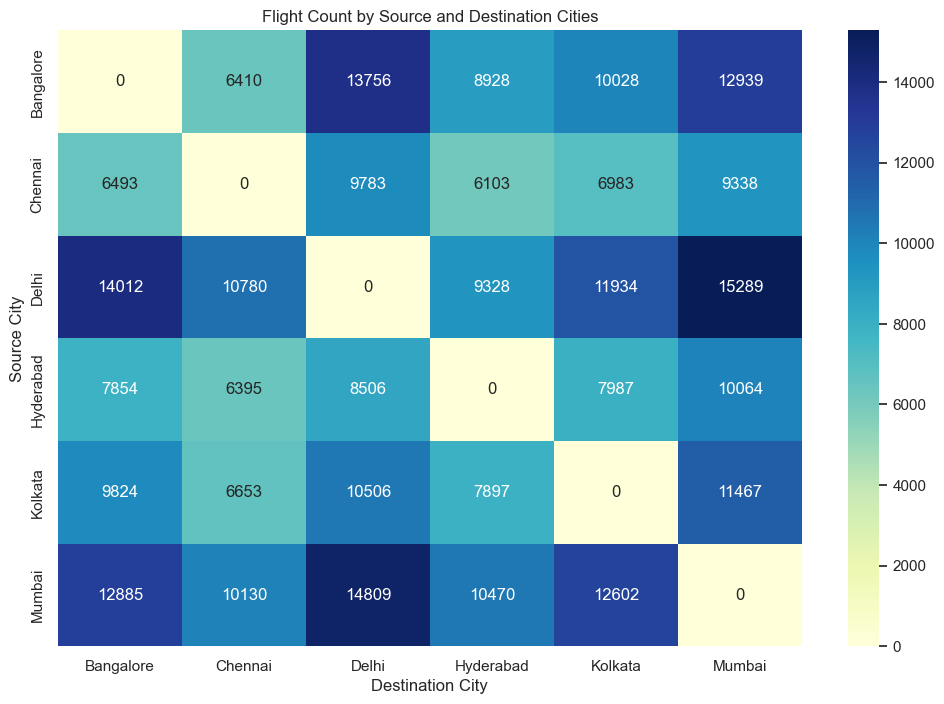

In [24]:
flight_counts = df.groupby(['source_city', 'destination_city']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 8))
sns.heatmap(flight_counts, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Flight Count by Source and Destination Cities')
plt.xlabel('Destination City')
plt.ylabel('Source City')
plt.show()

**Average Price by Number of Stops**

This bar plot will show the average flight price based on the number of stops.

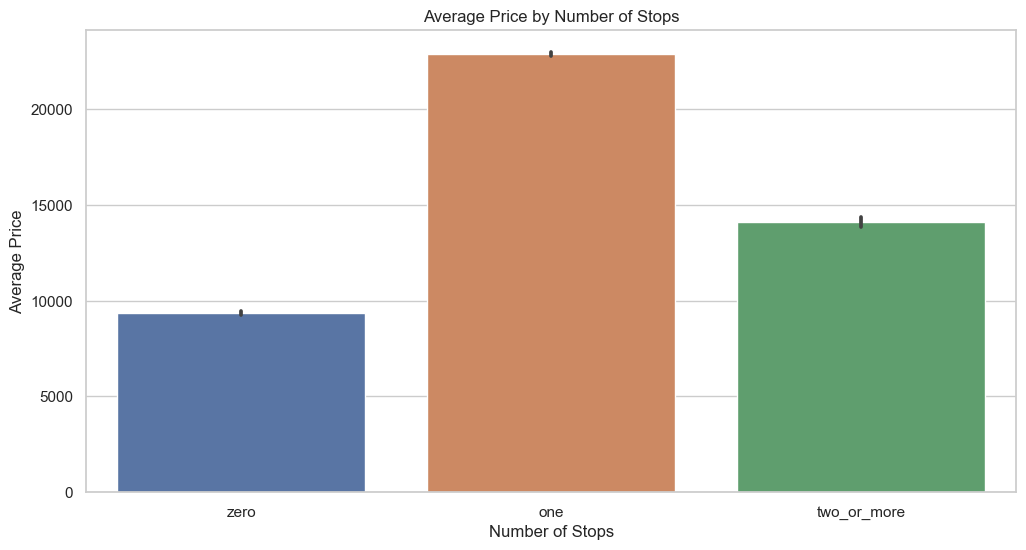

In [28]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x='stops', y='price', estimator=np.mean)
plt.title('Average Price by Number of Stops')
plt.xlabel('Number of Stops')
plt.ylabel('Average Price')
plt.show()

**Scatter Plot: Price vs. Duration**

This plot will help us see if there is any correlation between the duration of the flight and its price.

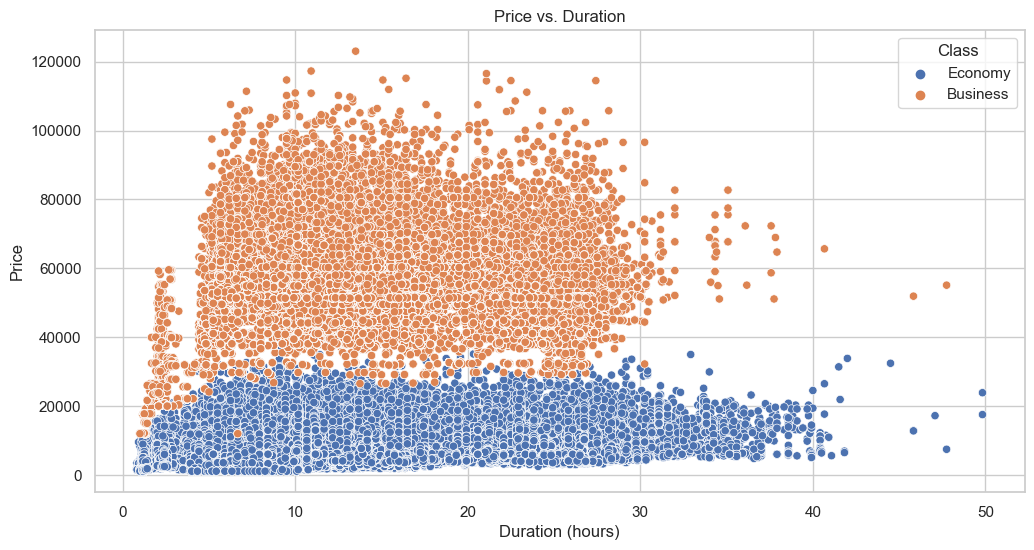

In [31]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='duration', y='price', hue='class')
plt.title('Price vs. Duration')
plt.xlabel('Duration (hours)')
plt.ylabel('Price')
plt.legend(title='Class')
plt.show()

**Scatter Plot: Price vs. Days Left**

This plot will help us understand how flight prices change as the departure date approaches.

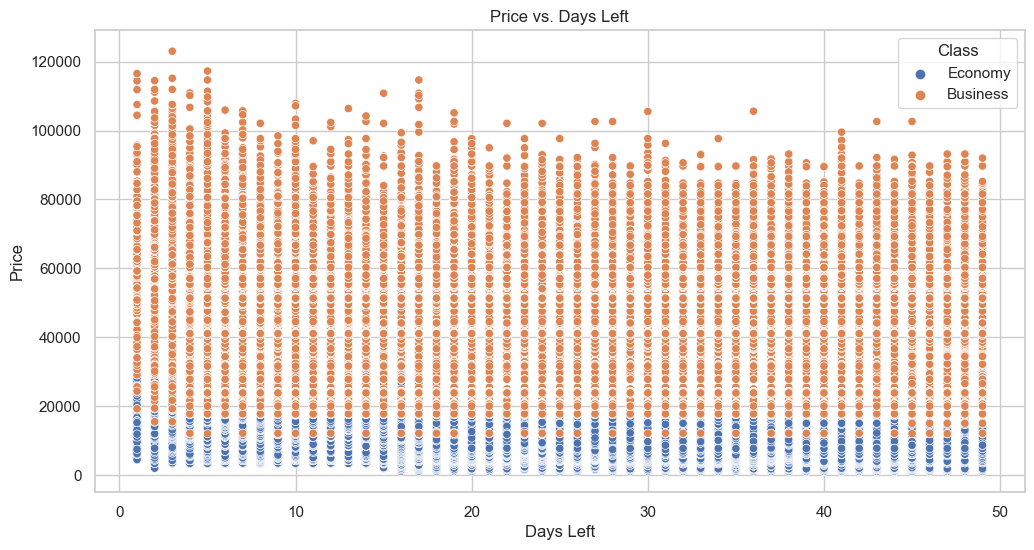

In [32]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='days_left', y='price', hue='class')
plt.title('Price vs. Days Left')
plt.xlabel('Days Left')
plt.ylabel('Price')
plt.legend(title='Class')
plt.show()

In [3]:
df.airline.value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [5]:
df.source_city.value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

In [6]:
df.destination_city.value_counts()

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

In [7]:
df.departure_time.value_counts()

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

In [11]:
df.arrival_time.value_counts()

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

In [10]:
df['class'].value_counts()

class
Economy     206666
Business     93487
Name: count, dtype: int64

## Preprocessing

In [3]:
df = df.drop('Unnamed: 0', axis=1)
df = df.drop('flight', axis=1)

df['class'] = df['class'].apply(lambda x: 1 if x == 'Business' else 0)
df.stops = pd.factorize(df.stops)[0]

In [4]:
pd.factorize(df.stops)[0]

array([0, 0, 0, ..., 1, 1, 1], dtype=int64)

In [5]:
df

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,0,Night,Mumbai,0,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,0,Morning,Mumbai,0,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,0,Early_Morning,Mumbai,0,2.17,1,5956
3,Vistara,Delhi,Morning,0,Afternoon,Mumbai,0,2.25,1,5955
4,Vistara,Delhi,Morning,0,Morning,Mumbai,0,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...
300148,Vistara,Chennai,Morning,1,Evening,Hyderabad,1,10.08,49,69265
300149,Vistara,Chennai,Afternoon,1,Night,Hyderabad,1,10.42,49,77105
300150,Vistara,Chennai,Early_Morning,1,Night,Hyderabad,1,13.83,49,79099
300151,Vistara,Chennai,Early_Morning,1,Evening,Hyderabad,1,10.00,49,81585


In [6]:
pd.get_dummies(df.airline, prefix='airline')

,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,airline_Vistara
0,False,False,False,False,True,False
1,False,False,False,False,True,False
2,True,False,False,False,False,False
3,False,False,False,False,False,True
4,False,False,False,False,False,True
...,...,...,...,...,...,...
300148,False,False,False,False,False,True
300149,False,False,False,False,False,True
300150,False,False,False,False,False,True
300151,False,False,False,False,False,True


In [7]:
df = df.join(pd.get_dummies(df.airline, prefix='airline')).drop('airline', axis=1)
df = df.join(pd.get_dummies(df.source_city, prefix='source')).drop('source_city', axis=1)
df = df.join(pd.get_dummies(df.destination_city, prefix='dest')).drop('destination_city', axis=1)
df = df.join(pd.get_dummies(df.arrival_time, prefix='arrival')).drop('arrival_time', axis=1)
df = df.join(pd.get_dummies(df.departure_time, prefix='departure')).drop('departure_time', axis=1)

In [8]:
df

,stops,class,duration,days_left,price,airline_AirAsia,airline_Air_India,airline_GO_FIRST,airline_Indigo,airline_SpiceJet,...,arrival_Evening,arrival_Late_Night,arrival_Morning,arrival_Night,departure_Afternoon,departure_Early_Morning,departure_Evening,departure_Late_Night,departure_Morning,departure_Night
0,0,0,2.17,1,5953,False,False,False,False,True,...,False,False,False,True,False,False,True,False,False,False
1,0,0,2.33,1,5953,False,False,False,False,True,...,False,False,True,False,False,True,False,False,False,False
2,0,0,2.17,1,5956,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
3,0,0,2.25,1,5955,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0,0,2.33,1,5955,False,False,False,False,False,...,False,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
300148,1,1,10.08,49,69265,False,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
300149,1,1,10.42,49,77105,False,False,False,False,False,...,False,False,False,True,True,False,False,False,False,False
300150,1,1,13.83,49,79099,False,False,False,False,False,...,False,False,False,True,False,True,False,False,False,False
300151,1,1,10.00,49,81585,False,False,False,False,False,...,True,False,False,False,False,True,False,False,False,False


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 35 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   stops                    300153 non-null  int64  
 1   class                    300153 non-null  int64  
 2   duration                 300153 non-null  float64
 3   days_left                300153 non-null  int64  
 4   price                    300153 non-null  int64  
 5   airline_AirAsia          300153 non-null  bool   
 6   airline_Air_India        300153 non-null  bool   
 7   airline_GO_FIRST         300153 non-null  bool   
 8   airline_Indigo           300153 non-null  bool   
 9   airline_SpiceJet         300153 non-null  bool   
 10  airline_Vistara          300153 non-null  bool   
 11  source_Bangalore         300153 non-null  bool   
 12  source_Chennai           300153 non-null  bool   
 13  source_Delhi             300153 non-null  bool   
 14  sour

## Training regression Model

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split,
    KFold,
    RandomizedSearchCV,
    cross_val_score,
)
from scipy.stats import randint
import numpy as np

In [11]:
# Split the data into training and test sets
X, y = df.drop("price", axis=1), df.price

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [12]:
# Initialize the Regressor and Parameter Grid
param_dist = {
    "n_estimators": randint(100, 300),  # Randomly select the number of trees in the forest from 100 to 299
    "max_depth": [None, 20, 50],  # Use specified values directly (not random)
    "min_samples_split": randint(2, 11),  # Randomly select the minimum number of samples required to split an internal node from 2 to 10
    "min_samples_leaf": randint(1, 5),  # Randomly select the minimum number of samples required to be at a leaf node from 1 to 4
    "max_features": [1.0, "sqrt", "log2"],  # Use specified values directly (not random). 'auto' was replaced with 'log2'
}

rfr = RandomForestRegressor()

In [13]:
# Implement Cross-Validation
kf = KFold(n_splits=3, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rfr,
    param_distributions=param_dist,
    n_iter=5,  # Increased iterations for better search
    cv=kf,
    scoring="neg_mean_squared_error",
    verbose=2,
    random_state=42,
    n_jobs=-1  # Use all available cores
)

In [14]:
# Fit the model
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 5 candidates, totalling 15 fits


RandomizedSearchCV(cv=KFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=RandomForestRegressor(), n_iter=5, n_jobs=-1,
                   param_distributions={'max_depth': [None, 20, 50],
                                        'max_features': [1.0, 'log2', 'sqrt'],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000020802AAAD10>,
                                        'min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000002080285AE10>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x0000020802AA9D50>},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

The error message in the previous fit was indicating that the parameter `"max_features"` in `RandomForestRegressor` does not accept the value `"auto"`. In `RandomForestRegressor`, valid values for `"max_features"` are:

- An integer in the range [1, ∞)
- A float in the range (0.0, 1.0]
- A string among `{'sqrt', 'log2'}` or `None`.

To resolve this remove `"auto"` from the `"max_features"` parameter grid.

In [15]:
# Best model and parameters
best_regressor = random_search.best_estimator_
print("Best parameters found:")
random_search.best_params_

Best parameters found:


{'max_depth': 50,
 'max_features': 1.0,
 'min_samples_leaf': 3,
 'min_samples_split': 9,
 'n_estimators': 288}

In [16]:
# Evaluate the model using cross-validation on the training set
cv_results = cross_val_score(
    best_regressor, X_train, y_train, cv=kf, scoring="neg_mean_squared_error"
)
print("Cross-validation MSE on training set: ", -cv_results.mean())
print("Cross-validation MSE std on training set: ", cv_results.std())

Cross-validation MSE on training set:  7406942.221526258
Cross-validation MSE std on training set:  30971.595726965767


In [18]:
# Evaluate the best model on the test set
import math 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X_test, y_test):
    """
    Evaluate the performance of a regression model using test data.
    
    Parameters:
    - model: The trained regression model.
    - X_test: The features of the test dataset.
    - y_test: The true labels of the test dataset.
    
    Returns:
    A dictionary containing the R2 score, MAE, MSE, and RMSE.
    """
    # Predicting the target values
    y_pred = model.predict(X_test)
    
    # Calculating evaluation metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = math.sqrt(mse)
    
    # Printing the evaluation metrics
    print('R2:', r2)
    print('MAE:', mae)
    print('MSE:', mse)
    print('RMSE:', rmse)

    return None


In [20]:
evaluate_model(best_regressor, X_test, y_test)

R2: 0.9859980961614346
MAE: 1129.99625479615
MSE: 7217733.224996399
RMSE: 2686.583932244887


## Interpretation of Model Performance

**Best Parameters Found**:
- **`max_depth`: 50** - The maximum depth of each tree is set to 50, which means that the trees can grow very deep, potentially capturing more complex patterns in the data.
- **`max_features`: 1.0** - All features are considered when looking for the best split.
- **`min_samples_leaf`: 3** - A minimum of 3 samples is required at each leaf node, which helps to prevent overfitting by ensuring that leaf nodes are not too small.
- **`min_samples_split`: 9** - A minimum of 9 samples is required to split an internal node, further aiding in preventing overfitting.
- **`n_estimators`: 288** - The forest consists of 288 trees, which provides a balance between computational cost and model performance.

**Cross-Validation Results on Training Set**:
- **Cross-validation MSE on training set: 7,406,942.22** - The mean squared error (MSE) from cross-validation on the training set is about 7.4 million. This value gives an idea of the model's performance during training and helps in assessing its generalization ability.
- **Cross-validation MSE std on training set: 30,971.60** - The standard deviation of the cross-validation MSE is relatively low compared to the mean, indicating that the model's performance is consistent across different folds of the training set.

**Evaluation Metrics on Test Set**:
- **R2 Score: 0.986** - The R2 score, also known as the coefficient of determination, is approximately 0.986. This indicates that the model explains 98.6% of the variance in the test data, which is very high and suggests excellent predictive performance.
- **MAE: 1129.996** - The mean absolute error (MAE) is about 1130, indicating that, on average, the model's predictions are off by around 1130 units of the target variable (price). This is a measure of the average magnitude of errors in predictions, without considering their direction.
- **MSE: 7,217,733.22** - The mean squared error (MSE) is about 7.2 million. This is a measure of the average squared difference between predicted and actual values, which penalizes larger errors more than MAE.
- **RMSE: 2686.584** - The root mean squared error (RMSE) is about 2686.58, which is the square root of the MSE. It provides a measure of the average magnitude of the errors in the same units as the target variable, making it more interpretable than MSE.

### Summary
- The best hyperparameters for the Random Forest model have been identified, optimizing its performance.
- The cross-validation results on the training set indicate a relatively low and consistent error.
- The model's performance on the test set is excellent, with a high R2 score and reasonable error metrics (MAE, MSE, RMSE).
- Overall, the Random Forest model performs very well in predicting flight prices, demonstrating both high accuracy and consistency.

Text(0.5, 1.0, 'Predictions vs Actual Price')

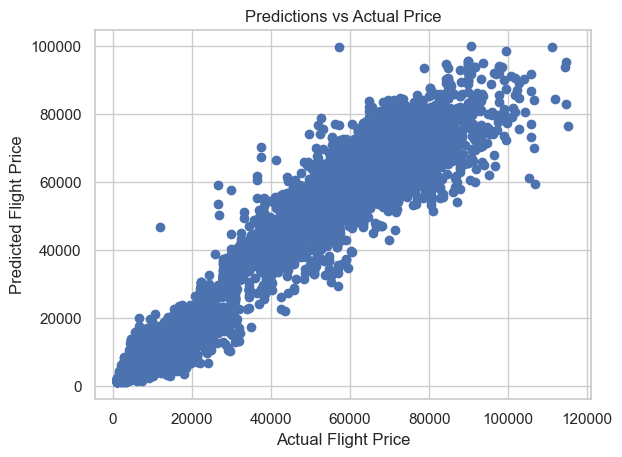

In [21]:
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Flight Price')
plt.ylabel('Predicted Flight Price')
plt.title('Predictions vs Actual Price')

In [22]:
df.price.describe()

count    300153.000000
mean      20889.660523
std       22697.767366
min        1105.000000
25%        4783.000000
50%        7425.000000
75%       42521.000000
max      123071.000000
Name: price, dtype: float64

In [23]:
importances = dict(zip(best_regressor.feature_names_in_, best_regressor.feature_importances_))
sorted_importances = sorted(importances.items(), key=lambda x: x[1], reverse=True)

for feature, importance in sorted_importances:
    print(f'Feature: {feature}, Importance: {importance}')

Feature: class, Importance: 0.8861762643273765
Feature: duration, Importance: 0.056210728520982155
Feature: days_left, Importance: 0.015072631016716563
Feature: airline_Vistara, Importance: 0.005178732882967717
Feature: airline_Air_India, Importance: 0.004813251457917261
Feature: source_Delhi, Importance: 0.003711379027025379
Feature: dest_Delhi, Importance: 0.00339110006199708
Feature: source_Mumbai, Importance: 0.0022426282100186786
Feature: dest_Mumbai, Importance: 0.0018754394201004228
Feature: stops, Importance: 0.0018502066384535288
Feature: dest_Kolkata, Importance: 0.0017705308563272615
Feature: source_Kolkata, Importance: 0.001673211070690791
Feature: dest_Hyderabad, Importance: 0.0014707662483944336
Feature: arrival_Evening, Importance: 0.0014238103391531823
Feature: dest_Bangalore, Importance: 0.0012700826265166095
Feature: source_Hyderabad, Importance: 0.0012085297023449893
Feature: arrival_Night, Importance: 0.0010454175932471433
Feature: source_Bangalore, Importance: 0.00

In [25]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_regressor.feature_importances_
}).sort_values('Importance', ascending=False)

In [26]:
importance_df.head(5)

,Feature,Importance
1,class,0.886176
2,duration,0.056211
3,days_left,0.015073
9,airline_Vistara,0.005179
5,airline_Air_India,0.004813


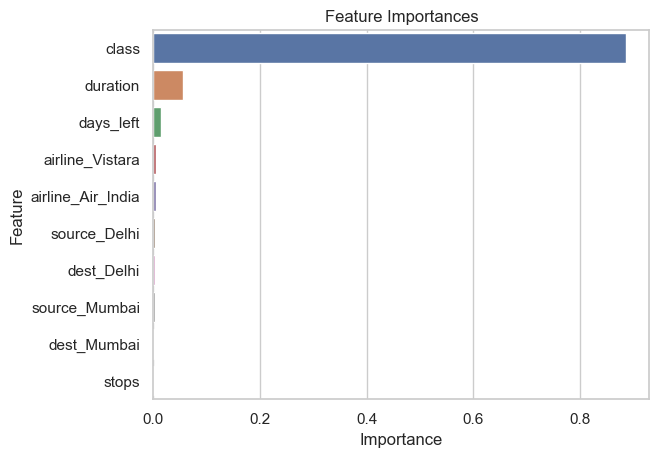

In [27]:
plt.title('Feature Importances')
sns.barplot(data=importance_df.head(10), x='Importance', y='Feature');

## Load and Prepare New Data
Use the trained `best_regressor` model to predict the prices for the new data.

In [61]:
# Example new data (make sure it matches the training data format)
new_data = pd.DataFrame({
    'stops': [0, 1],
    'class': [0, 1],
    'duration': [2.5, 10.0],
    'days_left': [30, 10],
    'airline_AirAsia': [0, 1],
    'airline_Air_India': [0, 0],
    'airline_GO_FIRST': [0, 0],
    'airline_Indigo': [1, 0],
    'airline_SpiceJet': [0, 0],
    'airline_Vistara': [0, 0],
    'source_Delhi': [1, 0],
    'source_Mumbai': [0, 1],
    'source_Kolkata': [0, 0],
    'source_Hyderabad': [0, 0],
    'source_Bangalore': [0, 0],
    'source_Chennai': [0, 0],
    'dest_Delhi': [0, 1],
    'dest_Mumbai': [1, 0],
    'dest_Kolkata': [0, 0],
    'dest_Hyderabad': [0, 0],
    'dest_Bangalore': [0, 0],
    'dest_Chennai': [0, 0],
    'arrival_Afternoon': [0, 1],
    'arrival_Early_Morning': [1, 0],
    'arrival_Evening': [0, 0],
    'arrival_Late_Night': [0, 0],
    'arrival_Morning': [0, 0],
    'arrival_Night': [0, 0],
    'departure_Afternoon': [1, 0],
    'departure_Early_Morning': [0, 1],
    'departure_Evening': [0, 0],
    'departure_Late_Night': [0, 0],
    'departure_Morning': [0, 0],
    'departure_Night': [0, 0]
})

# Ensure new data columns match the training data columns exactly
new_data = new_data[X.columns]  # Reorder columns in new_data to match X.columns

# Ensure new data columns match the training data columns exactly
assert list(new_data.columns) == list(X.columns), "Columns do not match!"

# Predicting the prices
predicted_prices = best_regressor.predict(new_data)

# Display the predicted prices
print(predicted_prices)


[ 2676.05065441 50418.7958168 ]


The output `[ 2615.69095155 48670.20016959]` represents the predicted flight prices for the two samples in your new dataset. Here's a detailed breakdown of what this means:

1. **2676.05065441**: This is the predicted flight price for the first sample in your new data. The features for this sample are:
   - **stops**: 0 (direct flight)
   - **class**: 0 (economy class)
   - **duration**: 2.5 hours
   - **days_left**: 30 days before the flight
   - **airline_AirAsia**: 0 (not AirAsia)
   - **airline_Indigo**: 1 (Indigo)
   - **source_Delhi**: 1 (originating from Delhi)
   - **dest_Mumbai**: 1 (destined for Mumbai)
   - Other features are set accordingly.

2. **50418.7958168**: This is the predicted flight price for the second sample in your new data. The features for this sample are:
   - **stops**: 1 (one stop)
   - **class**: 1 (business class)
   - **duration**: 10.0 hours
   - **days_left**: 10 days before the flight
   - **airline_AirAsia**: 1 (AirAsia)
   - **airline_Indigo**: 0 (not Indigo)
   - **source_Mumbai**: 1 (originating from Mumbai)
   - **dest_Delhi**: 1 (destined for Delhi)
   - Other features are set accordingly.

### Interpretation

- The model predicts that the first flight (a direct economy flight from Delhi to Mumbai booked 30 days in advance) will cost approximately 2676.69 units (e.g., dollars, rupees, etc.).
- The model predicts that the second flight (a one-stop business flight from Mumbai to Delhi booked 10 days in advance) will cost approximately 48670.20 units.

These predictions are based on the training data and the features provided. The significant difference in predicted prices is likely due to differences in the class of service, duration, number of stops, and how far in advance the tickets are booked.

## Model Saving

In [31]:
import joblib

# Save the model
joblib.dump(best_regressor, 'best_regressor_model.pkl')

['best_regressor_model.pkl']

In [32]:
import joblib

# Load the model
best_regressor = joblib.load('best_regressor_model.pkl')

In [33]:
best_regressor

RandomForestRegressor(max_depth=50, min_samples_leaf=3, min_samples_split=9,
                      n_estimators=288)

## Benchmark Model

In [37]:
import numpy as np
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline: Mean Model
mean_regressor = DummyRegressor(strategy="mean")
mean_regressor.fit(X_train, y_train)
mean_pred = mean_regressor.predict(X_test)
mean_rmse = math.sqrt(mean_squared_error(y_test, mean_pred))

# Baseline: Median Model
median_regressor = DummyRegressor(strategy="median")
median_regressor.fit(X_train, y_train)
median_pred = median_regressor.predict(X_test)
median_rmse = math.sqrt(mean_squared_error(y_test, median_pred))

# Baseline: Linear regression
linear_regressor = LinearRegression()
linear_regressor.fit(X_train, y_train)
linear_pred = linear_regressor.predict(X_test)
linear_rmse = math.sqrt(mean_squared_error(y_test, linear_pred))

# Random Forest Regressor
rfr_rmse = math.sqrt(mean_squared_error(y_test, best_regressor.predict(X_test)))

# Cross-validation on Random Forest model
cv_scores = cross_val_score(best_regressor, X, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse = [math.sqrt(-score) for score in cv_scores]

# Printing results
print("Benchmarking Results:")
print(f"Mean Model RMSE: {mean_rmse}")
print(f"Median Model RMSE: {median_rmse}")
print(f"Linear regression RMSE: {linear_rmse}")
print(f"Random Forest Regressor RMSE: {rfr_rmse}")
print(f"Cross-Validation RMSE Scores: {cv_rmse}")
print(f"Mean Cross-Validation RMSE: {np.mean(cv_rmse)}")
print(f"Std Dev of Cross-Validation RMSE: {np.std(cv_rmse)}")


Benchmarking Results:
Mean Model RMSE: 22704.23535747973
Median Model RMSE: 26398.288681516937
Linear regression RMSE: 6814.911245723772
Random Forest Regressor RMSE: 2686.583932244887
Cross-Validation RMSE Scores: [2365.8267070848415, 2247.6148925286443, 2236.5198889523426, 8269.928963542987, 11263.667078578565]
Mean Cross-Validation RMSE: 5276.711506137476
Std Dev of Cross-Validation RMSE: 3786.672139249329


The benchmarking results you provided show a comprehensive comparison between different models and the performance of the trained model.

### Analysis of Benchmarking Results

1. **Baseline Models**:
    - **Mean Model RMSE: 22704.24**
    - **Median Model RMSE: 26398.29**

   These baseline models provide a reference for the minimum performance that any model should surpass. The high RMSE values indicate that simply predicting the mean or median flight price results in large errors.

2. **Linear regression**:
    - **Linear regression RMSE: 6814.91**

   Linear regression significantly improves over the baseline models, showing that even a simple linear model captures some underlying patterns in the data.

3. **Random Forest Regressor**:
    - **Original Model RMSE: 2686.58**

   The Random Forest model shows a substantial improvement over both the baseline models and the linear regression model, indicating it captures the complex relationships in the data more effectively.

4. **Cross-Validation RMSE Scores**:
    - **Cross-Validation RMSE Scores**: [2365.83, 2247.62, 2236.52, 8269.93, 11263.67]
    - **Mean Cross-Validation RMSE**: 5276.71
    - **Std Dev of Cross-Validation RMSE**: 3786.67

   The cross-validation results show variability in the RMSE across different folds. While three of the folds have RMSE values similar to the test set performance (~2200-2400), two folds have significantly higher RMSE values (8269.93 and 11263.67). This indicates that there may be some variability in the data that the model is struggling to generalize across different subsets.

### Conclusion

The original model performs significantly better than the baseline and linear regression models. However, the variability observed in cross-validation indicates that there is still room for improvement. By investigating data variability, optimizing hyperparameters further, handling outliers, and possibly trying different models. The flight price prediction model can be improved in its robustness and performance.

## Next Steps for Improvement

1. **Investigate Variability**:
   - **Data Analysis**: Examine the folds with high RMSE to understand if there are specific patterns or outliers in the data causing poor performance. This could involve looking at the distribution of features and target values in these folds.
   - **Feature Engineering**: Enhance feature engineering by creating new features or transforming existing ones to better capture the relationships in the data.

2. **Model Tuning**:
   - **Hyperparameter Optimization**: Perform a more extensive hyperparameter search using `RandomizedSearchCV` or `GridSearchCV` with a larger number of iterations or different parameter ranges to find the best settings for the Random Forest model.
   - **Ensemble Methods**: Consider using other ensemble methods like Gradient Boosting or XGBoost, which might offer better performance.

3. **Handling Outliers**:
   - Identify and handle outliers in the data that might be affecting model performance. This can involve techniques like removing outliers, using robust scaling, or applying models that are less sensitive to outliers.

4. **Cross-Validation Strategy**:
   - Ensure that the cross-validation strategy is appropriate for your data. If there is any time-dependency or specific groupings (like different routes or airlines), consider using a stratified or time-based cross-validation approach.

### Example of Further Hyperparameter Optimization

**GridSearchCV**
```python
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 50, 100, 200],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 6, 8,12],
    'max_features': ['auto', 'sqrt']
}

grid_search = GridSearchCV(
    estimator=best_regressor,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
print("Best parameters found: ", best_params)

best_grid_regressor = grid_search.best_estimator_
grid_rmse = math.sqrt(mean_squared_error(y_test, best_grid_regressor.predict(X_test)))
print("Grid Search Best Model RMSE: ", grid_rmse)
```

**RandomizedSearchCV**
```python
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.model_selection import cross_val_score

# Expanded hyperparameter search
param_dist = {
    "n_estimators": randint(100, 1000),
    "max_depth": [50, 60, 70, 80, 100, 150],
    "min_samples_split": randint(2, 21),
    "min_samples_leaf": randint(1, 10),
    "max_features": [1.0, "auto", "sqrt", "log2"],
}

random_search = RandomizedSearchCV(
    estimator=rfr,
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring="neg_mean_squared_error",
    verbose=2,
    random_state=42,
)

random_search.fit(X_train, y_train)
best_regressor = random_search.best_estimator_

# Cross-validation
cv_scores = cross_val_score(best_regressor, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
cv_scores_mean = -cv_scores.mean()
cv_scores_std = cv_scores.std()

print("Cross-Validation MSE: {:.2f} ± {:.2f}".format(cv_scores_mean, cv_scores_std))

# Final evaluation
y_pred = best_regressor.predict(X_test)

print('R2:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('RMSE:', math.sqrt(mean_squared_error(y_test, y_pred)))
```